In [6]:
import pandas as pd

url = "https://raw.githubusercontent.com/Pranjali1049/Salary_Prediction/main/Salary_Data.csv"

df = pd.read_csv(url)

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [7]:
df.shape

(6704, 6)

In [8]:
df = df.head(1000)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  998 non-null    float64
 1   Gender               998 non-null    object 
 2   Education Level      998 non-null    object 
 3   Job Title            998 non-null    object 
 4   Years of Experience  998 non-null    float64
 5   Salary               998 non-null    float64
dtypes: float64(3), object(3)
memory usage: 47.0+ KB


In [10]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


In [11]:
df = df.dropna()

In [12]:
df.isnull().sum()

,0
Age,0
Gender,0
Education Level,0
Job Title,0
Years of Experience,0
Salary,0


In [13]:
df.duplicated().sum()

np.int64(571)

In [14]:
df = df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
import matplotlib.pyplot as plt

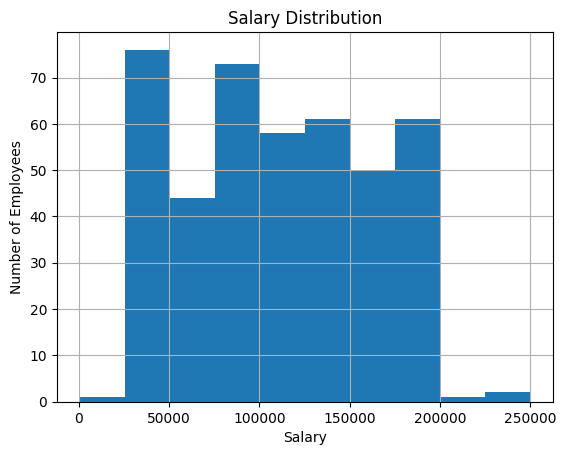

In [17]:
df["Salary"].hist()
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.show()

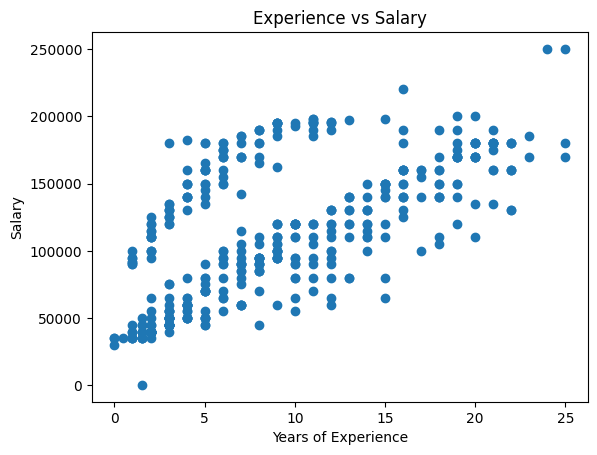

In [18]:
plt.scatter(df["Years of Experience"], df["Salary"])
plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [19]:
X = df[["Years of Experience"]]
y = df["Salary"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 30863.376903605214
MSE: 1497693073.9388971
R2 Score: 0.4252674646042479


In [24]:
experience = [[5]]   # Change 5 to any years of experience
predicted_salary = model.predict(experience)

print("Predicted Salary:", predicted_salary[0])

Predicted Salary: 91640.52848532484


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


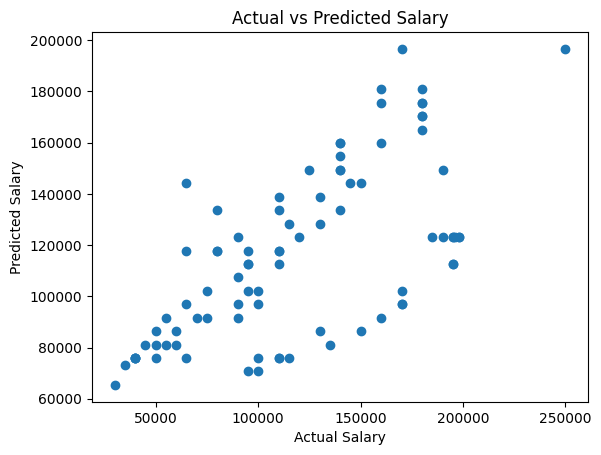

In [25]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

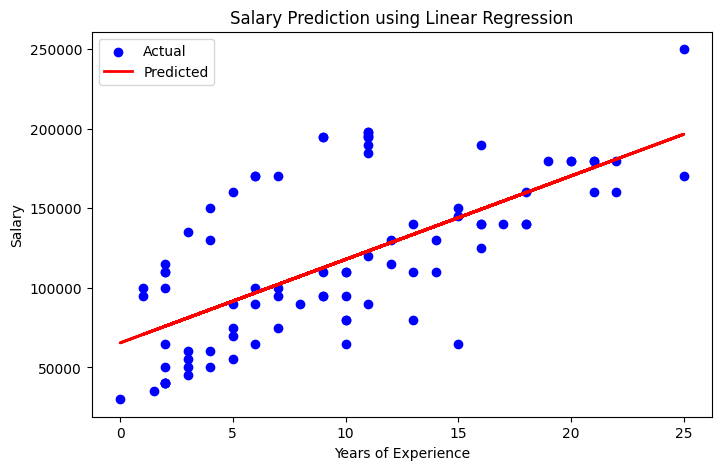

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, color="blue", label="Actual")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Predicted")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Prediction using Linear Regression")
plt.legend()
plt.show()

In [28]:
from sklearn.metrics import r2_score

print("Model Accuracy:", round(r2_score(y_test, y_pred) * 100, 2), "%")

Model Accuracy: 42.53 %
